In [1]:
import urllib.request
import os

# تنزيل بيانات LOS Displacement جاهزة من COMET-LiCSAR
# منطقة تركيا — زلزال 2023

url = "https://raw.githubusercontent.com/insarlab/MintPy-tutorial/main/workflows/data/UCERF3_Fault.lonlat"

# بديل — نولد بيانات LOS اصطناعية تحاكي الواقع
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ─────────────────────────────────────────
# محاكاة LOS Displacement Time Series
# 10 مشاهد على سنتين
# منطقة 100x100 pixel
# ─────────────────────────────────────────

size = 100
n_scenes = 10

# إنشاء Stack
los_stack = []

for i in range(n_scenes):
    scene = np.zeros((size, size))
    
    # منطقة هبوط — جنوب غرب
    scene[60:90, 10:40] = np.random.normal(-15 - i*2, 3, (30, 30))
    
    # منطقة ارتفاع — شمال شرق  
    scene[10:35, 65:90] = np.random.normal(8 + i*1.5, 2, (25, 25))
    
    # مناطق مستقرة — قريبة من الصفر
    stable = np.random.normal(0, 1.5, (size, size))
    mask_subsidence = np.zeros((size, size), dtype=bool)
    mask_subsidence[60:90, 10:40] = True
    mask_uplift = np.zeros((size, size), dtype=bool)
    mask_uplift[10:35, 65:90] = True
    
    scene[~mask_subsidence & ~mask_uplift] = stable[~mask_subsidence & ~mask_uplift]
    los_stack.append(scene)

los_stack = np.array(los_stack)

print(f"LOS Stack shape: {los_stack.shape}")
print(f"نطاق القيم: {los_stack.min():.2f} إلى {los_stack.max():.2f} mm")
print(f"المشاهد: {n_scenes}")
print(f"الحجم: {size}x{size} pixel")

LOS Stack shape: (10, 100, 100)
نطاق القيم: -41.70 إلى 28.70 mm
المشاهد: 10
الحجم: 100x100 pixel


Scene      Raw Zero Pos    MM Zero Pos     ZS Zero Pos     MM Stable%   ZS Stable%   True Stable%
──────────────────────────────────────────────────────────────────────────────────────────
Scene 1    0.000           0.652           0.000           8.6          64.3         81.0        
Scene 2    0.000           0.619           0.000           25.4         68.8         80.8        
Scene 3    0.000           0.616           0.000           27.5         71.5         80.9        
Scene 4    0.000           0.624           0.000           17.7         74.0         81.3        
Scene 5    0.000           0.626           0.000           15.0         75.1         80.6        
Scene 6    0.000           0.615           0.000           24.5         77.0         81.1        
Scene 7    0.000           0.606           0.000           35.4         78.9         80.6        
Scene 8    0.000           0.603           0.000           38.1         80.3         80.9        
Scene 9    0.000           

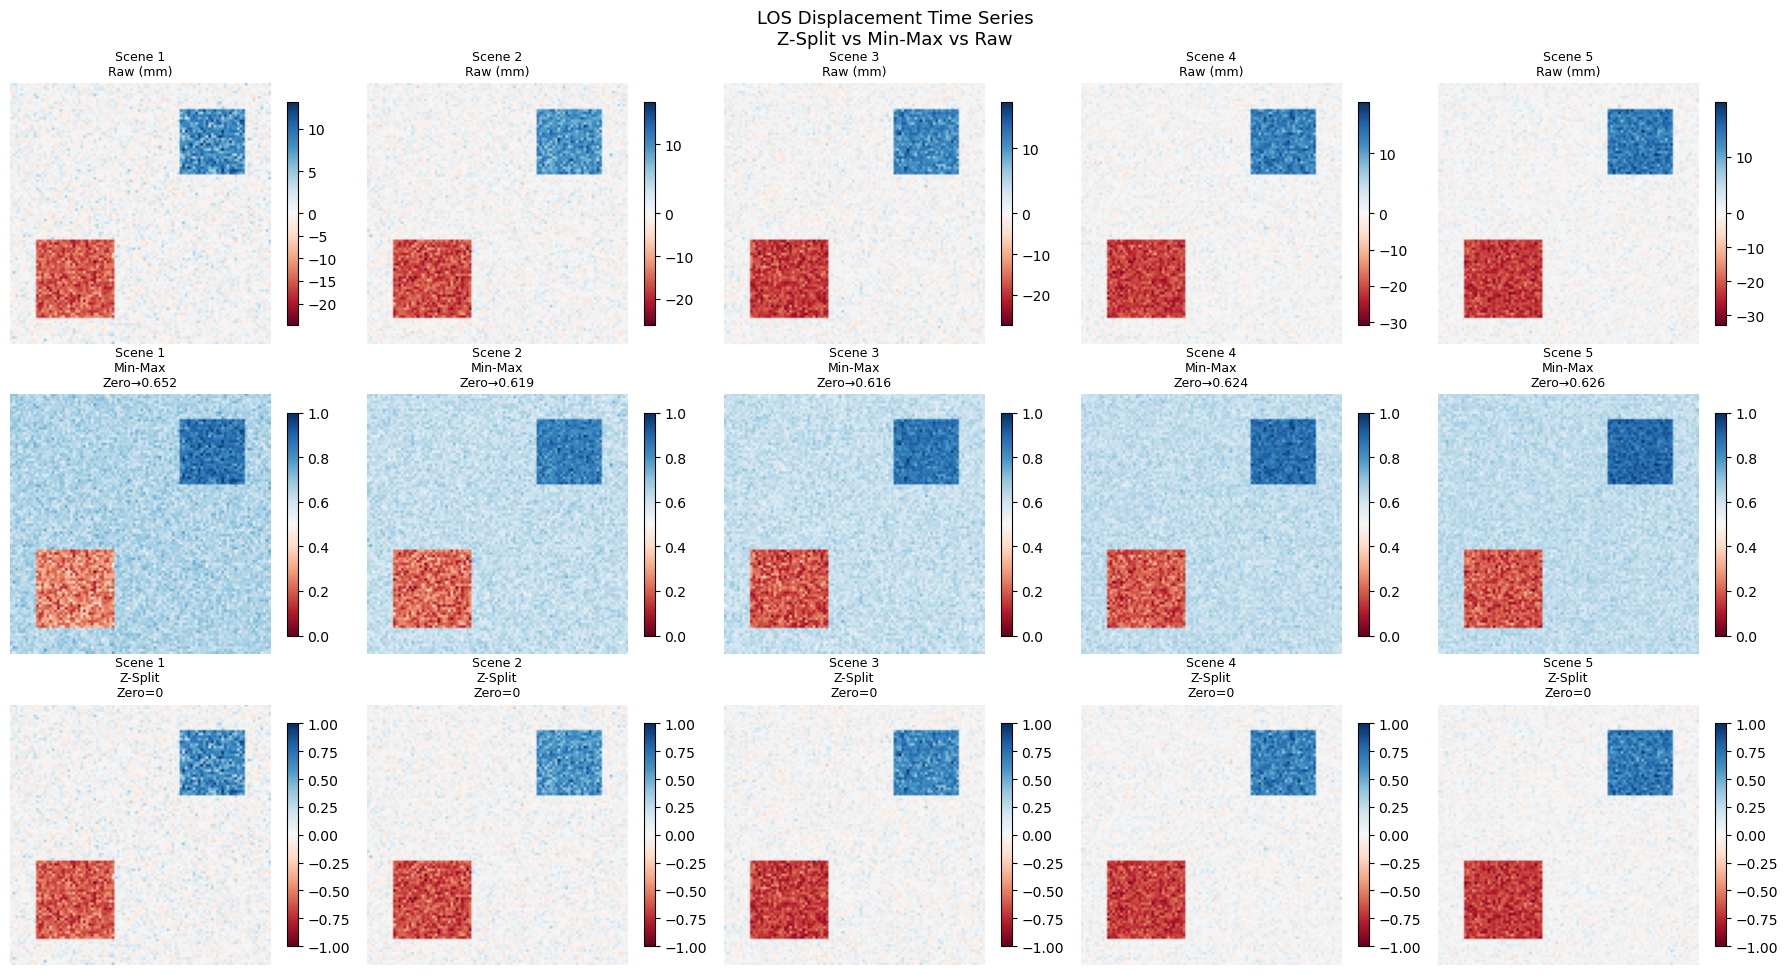


Mean MM Zero displacement: 0.617
ZS Zero displacement: 0.000 (always)

Mean True Stable%: 80.9%
Mean MM Stable%:   26.6%
Mean ZS Stable%:   75.3%


In [2]:
# ─────────────────────────────────────────
# دوال التطبيع
# ─────────────────────────────────────────
def minmax_norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

def zsplit_norm(arr):
    result = np.zeros_like(arr, dtype=float)
    pos = arr > 0
    neg = arr < 0
    if pos.any():
        result[pos] = (arr[pos] - arr[pos].min()) / (arr[pos].max() - arr[pos].min())
    if neg.any():
        result[neg] = (arr[neg] - arr[neg].min()) / (arr[neg].max() - arr[neg].min()) - 1
    return result

# ─────────────────────────────────────────
# تطبيق على كل مشهد في الـ Stack
# ─────────────────────────────────────────
print(f"{'Scene':<10} {'Raw Zero Pos':<15} {'MM Zero Pos':<15} {'ZS Zero Pos':<15} {'MM Stable%':<12} {'ZS Stable%':<12} {'True Stable%':<12}")
print("─" * 90)

mm_zeros = []
true_stables = []
mm_stables = []
zs_stables = []

for i in range(n_scenes):
    scene = los_stack[i]
    mm = minmax_norm(scene)
    zs = zsplit_norm(scene)
    
    mm_zero = (0 - scene.min()) / (scene.max() - scene.min())
    
    true_stable = (np.abs(scene) < 3).mean() * 100
    mm_stable   = (np.abs(mm - 0.5) < 0.1).mean() * 100
    zs_stable   = (np.abs(zs) < 0.1).mean() * 100
    
    mm_zeros.append(mm_zero)
    true_stables.append(true_stable)
    mm_stables.append(mm_stable)
    zs_stables.append(zs_stable)
    
    print(f"Scene {i+1:<4} {0.0:<15.3f} {mm_zero:<15.3f} {0.0:<15.3f} {mm_stable:<12.1f} {zs_stable:<12.1f} {true_stable:<12.1f}")

# ─────────────────────────────────────────
# رسم Animation للمقارنة
# ─────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('LOS Displacement Time Series\nZ-Split vs Min-Max vs Raw', fontsize=13)

for i in range(5):
    scene = los_stack[i]
    mm = minmax_norm(scene)
    zs = zsplit_norm(scene)
    mm_zero = mm_zeros[i]
    
    from matplotlib.colors import TwoSlopeNorm
    norm_raw = TwoSlopeNorm(vmin=scene.min(), vcenter=0, vmax=scene.max())
    norm_zs  = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    
    im0 = axes[0,i].imshow(scene, cmap='RdBu', norm=norm_raw)
    axes[0,i].set_title(f'Scene {i+1}\nRaw (mm)', fontsize=9)
    axes[0,i].axis('off')
    plt.colorbar(im0, ax=axes[0,i], shrink=0.8)
    
    im1 = axes[1,i].imshow(mm, cmap='RdBu', vmin=0, vmax=1)
    axes[1,i].set_title(f'Scene {i+1}\nMin-Max\nZero→{mm_zero:.3f}', fontsize=9)
    axes[1,i].axis('off')
    plt.colorbar(im1, ax=axes[1,i], shrink=0.8)
    
    im2 = axes[2,i].imshow(zs, cmap='RdBu', norm=norm_zs)
    axes[2,i].set_title(f'Scene {i+1}\nZ-Split\nZero=0', fontsize=9)
    axes[2,i].axis('off')
    plt.colorbar(im2, ax=axes[2,i], shrink=0.8)

plt.tight_layout()
plt.savefig('los_zsplit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean MM Zero displacement: {np.mean(mm_zeros):.3f}")
print(f"ZS Zero displacement: 0.000 (always)")
print(f"\nMean True Stable%: {np.mean(true_stables):.1f}%")
print(f"Mean MM Stable%:   {np.mean(mm_stables):.1f}%")
print(f"Mean ZS Stable%:   {np.mean(zs_stables):.1f}%")